<a href="https://colab.research.google.com/github/nananana25/MSC151/blob/main/A4_MSCI151.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
!pip install pulp

In [8]:
df = pd.read_excel('/content/MSCI151 Data.xlsx')
display(df.head())

,id,Profitability,debt,RnD,Firm Age,Firm Size,CEO Experience,foreign sales,CEO education,CEO Gender
0,1,0.02,23.76,53.09,3.43,21.22,2,9.16,2,0
1,2,3.99,41.85,45.30,3.22,21.83,4,41.42,1,0
2,3,41.98,61.84,51.16,3.18,20.54,3,5.88,3,1
3,4,8.48,25.61,115.49,3.26,20.59,3,11.08,2,0
4,5,-1.94,74.24,13.57,3.26,18.73,3,24.61,1,0


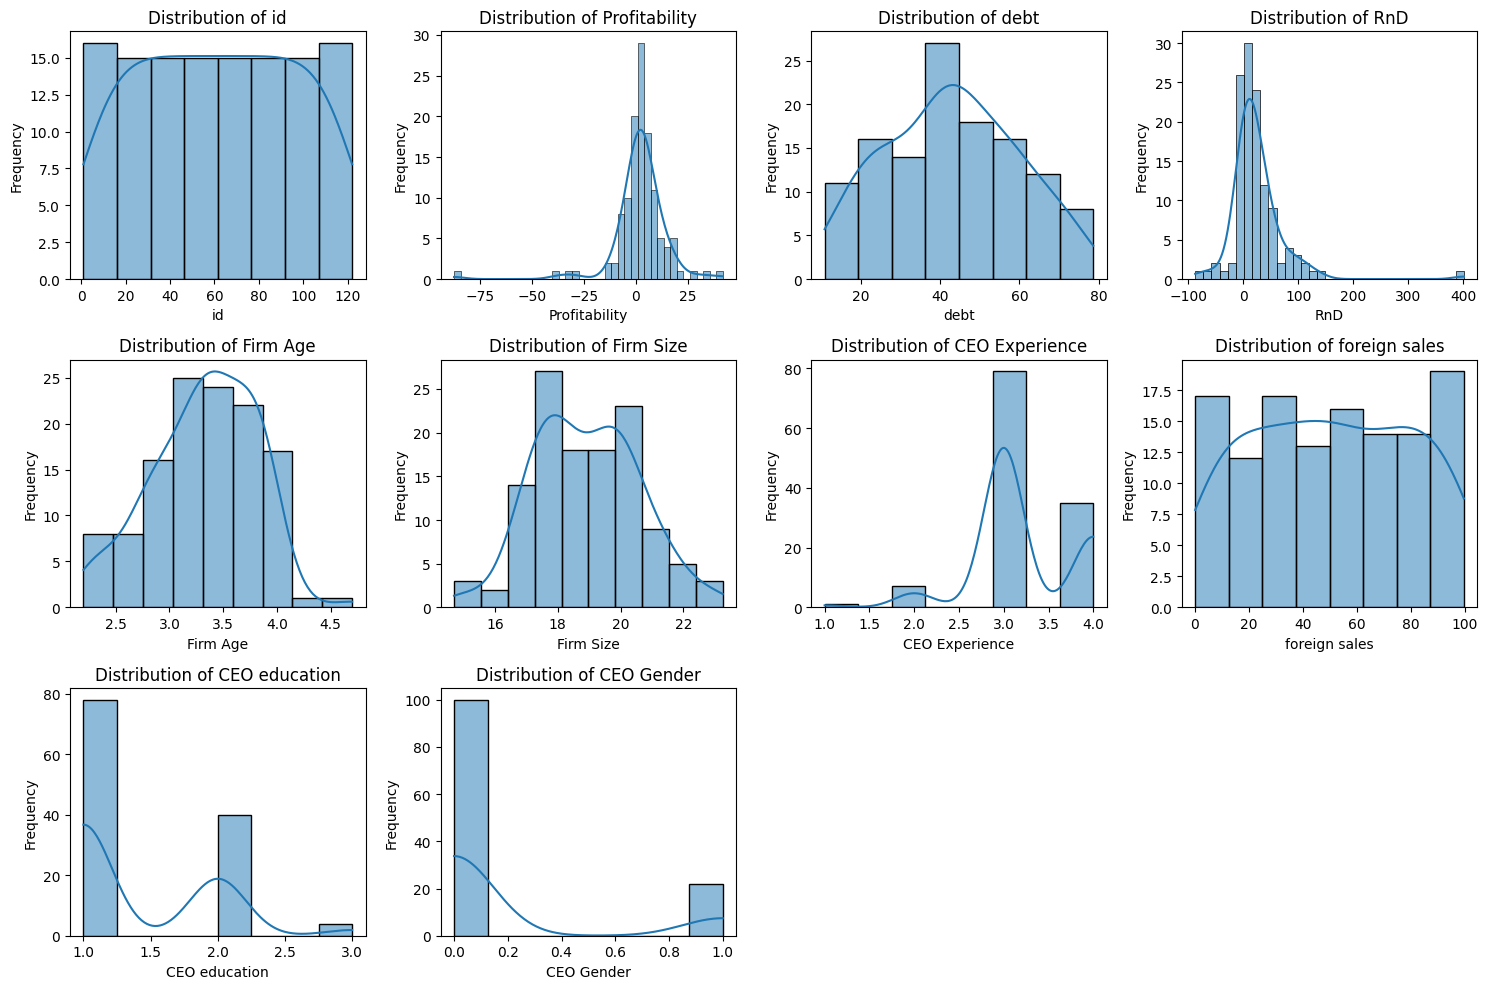

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for distribution plotting
numerical_cols = df.select_dtypes(include=['number']).columns

# Set up the matplotlib figure
plt.figure(figsize=(15, 10))

# Loop through each numerical column and plot its distribution
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              122 non-null    int64  
 1   Profitability   122 non-null    float64
 2   debt            122 non-null    float64
 3   RnD             122 non-null    float64
 4   Firm Age        122 non-null    float64
 5   Firm Size       122 non-null    float64
 6   CEO Experience  122 non-null    int64  
 7   foreign sales   122 non-null    float64
 8   CEO education   122 non-null    int64  
 9   CEO Gender      122 non-null    int64  
dtypes: float64(6), int64(4)
memory usage: 9.7 KB


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
from sklearn.model_selection import train_test_split # Added this import

# Define features (X) and target (Y)
# Identify target and features from the available 'df' DataFrame
target_column = 'Profitability'
# Features are all numerical columns except 'id' and the target column
feature_columns = [col for col in df.select_dtypes(include=['number']).columns if col not in ['id', target_column]]

X = df[feature_columns]
y = df[target_column]

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

# Make predictions on the test data
Y_pred = model.predict(X_test)

# Calculate RMSE and MAE
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
mae = mean_absolute_error(Y_test, Y_pred)

# Display the results
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

RMSE: 10.661938121711264
MAE: 8.492703999999998


## Random Forest Feature Importance

Let's visualize the feature importance from the trained Random Forest model. This will help us understand which features contribute most to the model's predictions.

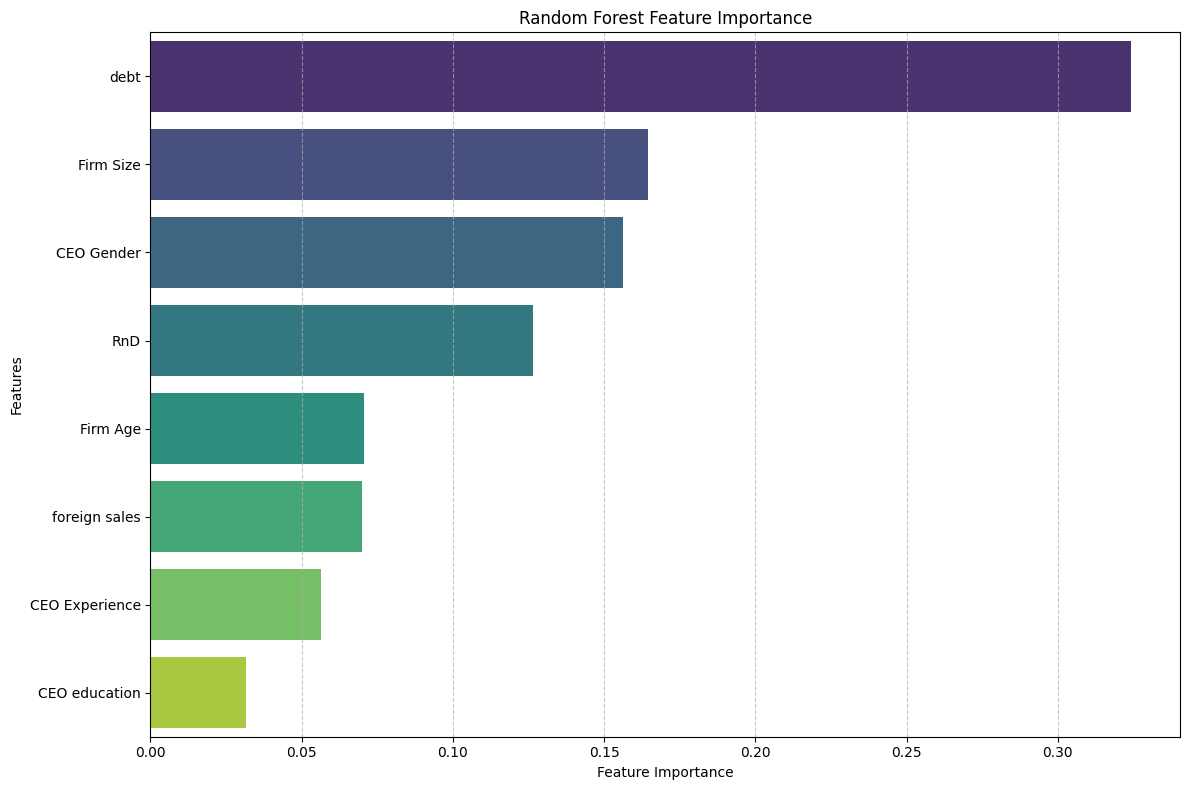

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Random Forest model
feature_importances = model.feature_importances_

# Create a pandas Series for easier handling and sorting
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Random Forest Feature Importance')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

XAI ANALYSIS

## Principal Component Analysis (PCA)

We performed PCA to reduce the dimensionality of your features. The analysis showed how much variance each principal component explains, and we retained 4 components, capturing about 65.5% of the total variance.

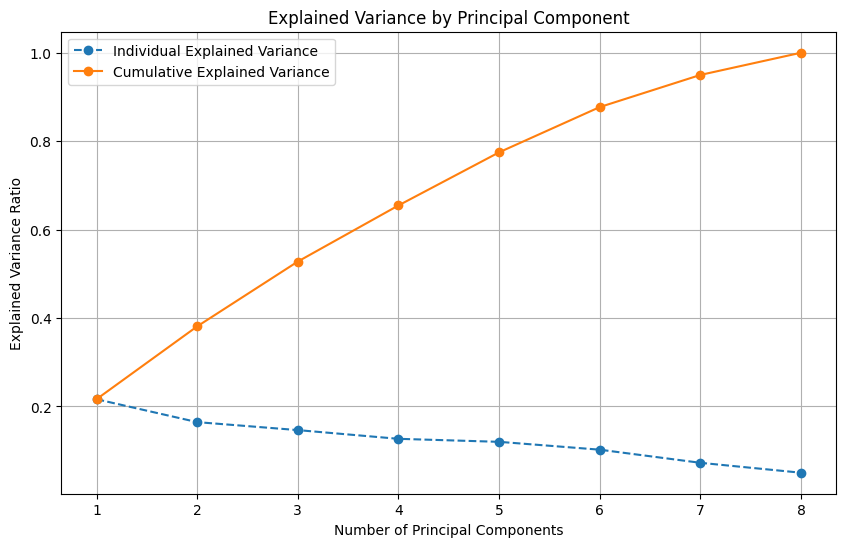

Explained Variance Ratio per component: [0.21646528 0.1646637  0.14662025 0.12690747 0.12010641 0.10233441
 0.07266299 0.05023949]
Cumulative Explained Variance: [0.21646528 0.38112897 0.52774923 0.6546567  0.77476311 0.87709752
 0.94976051 1.        ]


In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Standardize the features before applying PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
pca.fit(X_scaled)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', label='Individual Explained Variance')
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_explained_variance, marker='o', linestyle='-', label='Cumulative Explained Variance')
plt.title('Explained Variance by Principal Component')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.legend()
plt.show()

# Display the components
print("Explained Variance Ratio per component:", explained_variance_ratio)
print("Cumulative Explained Variance:", cumulative_explained_variance)

From the plot, you can decide how many principal components to retain based on the desired cumulative explained variance. For example, if you want to retain 95% of the variance, you'd choose the number of components where the cumulative line crosses 0.95.

In [17]:
# Example: Transform X into 3 principal components (adjust based on your analysis of the plot)
# You might want to choose a different number of components based on the scree plot
# For demonstration, let's select a reasonable number of components, e.g., 3 or 4.
n_components_to_retain = 4 # You can change this based on the plot
pca_final = PCA(n_components=n_components_to_retain)
X_pca = pca_final.fit_transform(X_scaled)

print(f"Transformed features with {n_components_to_retain} principal components. Shape: {X_pca.shape}")
# display(pd.DataFrame(X_pca, columns=[f'PC_{i+1}' for i in range(n_components_to_retain)]).head())

Transformed features with 4 principal components. Shape: (122, 4)


Analysis of PCA Results:
Variance Explained by Each Component: The first principal component (PC1) alone captures approximately 21.6% of the total variance in your original 8 features. PC2 captures about 16.5%, and so on. This indicates that the first few components capture a significant portion of the information present in your data.

Cumulative Variance: This is crucial for dimensionality reduction. By retaining 4 principal components (as we did for X_pca), you are collectively explaining about 65.5% of the total variance from the original 8 features. If your goal is to significantly reduce the number of features while retaining a large portion of the information, 4 components might be a reasonable trade-off, depending on your requirements for information retention.

For example, if you wanted to capture 95% of the variance, you would need 7 principal components, as shown by the cumulative_explained_variance value of 0.94976051 at the 7th component.
Dimensionality Reduction: The original X had 8 features. After PCA, we transformed X into X_pca, which now has 4 features (the 4 principal components). This effectively reduces the dimensionality of your dataset from 8 to 4, which can be beneficial for several reasons:

Reduced Computational Cost: Models trained on X_pca will run faster.
Mitigation of Multicollinearity: Principal components are orthogonal (uncorrelated) to each other, addressing the multicollinearity issues that were flagged in the OLS regression.
Noise Reduction: Lower-variance components (which are often dropped) might represent noise in the data.
Next Steps with PCA:
Now that you have X_pca (your data transformed into 4 principal components), you can:

Train Models on X_pca: You could re-train your Random Forest, OLS, or Lasso models using X_pca as the feature set instead of the original X. This would allow you to see if the models perform better or more efficiently with reduced and decorrelated features.
Visualization: For higher-dimensional data, the first two or three principal components can be used to visualize clusters or patterns that might not be apparent in the original feature space.

## Ordinary Least Squares (OLS) Regression

Next, let's fit an Ordinary Least Squares (OLS) model using `statsmodels` to understand the linear relationships between our features and the target variable `y`. We need to add a constant to the feature matrix for `statsmodels` to properly calculate the intercept.

In [18]:
import statsmodels.api as sm

# Add a constant to the feature matrix X for OLS regression (for the intercept term)
X_ols = sm.add_constant(X)

# Create and fit the OLS model
ols_model = sm.OLS(y, X_ols)
ols_results = ols_model.fit()

# Display the OLS regression summary
print(ols_results.summary())

                            OLS Regression Results                            
Dep. Variable:          Profitability   R-squared:                       0.270
Model:                            OLS   Adj. R-squared:                  0.218
Method:                 Least Squares   F-statistic:                     5.220
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           1.45e-05
Time:                        13:21:32   Log-Likelihood:                -466.32
No. Observations:                 122   AIC:                             950.6
Df Residuals:                     113   BIC:                             975.9
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.8223     14.148     -0.

Analyzing Ordinary Least Squares (OLS) Regression
Model Summary (from ols_results.summary()):

- R-squared and Adjusted R-squared: These indicate the proportion of variance in the dependent variable that can be predicted from the independent variables.

- Higher values (closer to 1) are generally better. Adjusted R-squared is preferred when comparing models with different numbers of predictors, as it accounts for the number of predictors in the model.

- F-statistic and Prob (F-statistic): The F-statistic tests the overall significance of the regression model. A low p-value (Prob (F-statistic) < 0.05) suggests that at least one of the predictors is significantly related to the dependent variable.

- Coefficients (coef): These values represent the change in the dependent variable for a one-unit change in the respective independent variable, holding other variables constant.

- Interpretation: A positive coefficient means that as the predictor increases, the target variable tends to increase. A negative coefficient means the opposite.

- Standard Error (std err): This measures the precision of the coefficient estimates. Smaller standard errors indicate more precise estimates.

- t-statistic and P>|t| (p-value): The t-statistic tests whether each individual predictor's coefficient is significantly different from zero. A low p-value (P>|t| < 0.05) indicates that the predictor is statistically significant.

- Confidence Interval ([0.025 0.975]): This provides a range within which the true coefficient value is likely to fall.

- Assumptions Check: OLS relies on several assumptions. Violations can affect the validity of the results.

- Linearity: The relationship between predictors and the target is linear.
- Independence of Errors: Residuals (errors) are independent.
- Homoscedasticity: The variance of the residuals is constant across all levels of the predictors.
- Normality of Errors: Residuals are normally distributed.
- No Multicollinearity: Predictor variables are not highly correlated with each other. (We saw a high condition number in our OLS results, suggesting multicollinearity.)
- Residual Analysis: Plotting residuals (predicted vs. actual, residuals vs. fitted values) can help check assumptions.

## Lasso Regression

Finally, let's implement Lasso Regression, which is a linear model with L1 regularization. Lasso can perform feature selection by shrinking some coefficients to zero, helping to prevent overfitting and identify the most important features. We will use the `X_train` and `Y_train` data that was already split for the Random Forest model.

In [19]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# It's important to scale the data for Lasso regression as it's sensitive to feature scales
scaler_lasso = StandardScaler()
X_train_scaled_lasso = scaler_lasso.fit_transform(X_train)
X_test_scaled_lasso = scaler_lasso.transform(X_test)

# Initialize and train the Lasso model
# The 'alpha' parameter controls the strength of regularization. You might need to tune this.
lasso_model = Lasso(alpha=0.1, random_state=42) # alpha=0.1 is an initial guess, tune as needed
lasso_model.fit(X_train_scaled_lasso, Y_train)

# Make predictions on the scaled test data
Y_pred_lasso = lasso_model.predict(X_test_scaled_lasso)

# Evaluate the Lasso model
rmse_lasso = np.sqrt(mean_squared_error(Y_test, Y_pred_lasso))
mae_lasso = mean_absolute_error(Y_test, Y_pred_lasso)

print(f"Lasso Regression RMSE: {rmse_lasso}")
print(f"Lasso Regression MAE: {mae_lasso}")

# Display the coefficients learned by the Lasso model
lasso_coefficients = pd.Series(lasso_model.coef_, index=X.columns)
print("\nLasso Coefficients (scaled features):")
print(lasso_coefficients[lasso_coefficients != 0].sort_values(ascending=False))
print("Number of features with non-zero coefficients:", (lasso_coefficients != 0).sum())

Lasso Regression RMSE: 9.73453178351336
Lasso Regression MAE: 7.969789723502701

Lasso Coefficients (scaled features):
CEO Gender        4.342297
RnD               2.241084
CEO Experience    1.752174
CEO education     1.461495
Firm Size         0.375065
foreign sales    -0.636011
Firm Age         -1.150955
debt             -3.594161
dtype: float64
Number of features with non-zero coefficients: 8


Analyzing Lasso Regression
Lasso (Least Absolute Shrinkage and Selection Operator) is a regularization technique that performs both variable selection and shrinkage.

Evaluation Metrics (RMSE, MAE):

RMSE (Root Mean Squared Error): This measures the average magnitude of the errors. It's sensitive to large errors. Lower RMSE is better.
MAE (Mean Absolute Error): This measures the average magnitude of the errors, giving equal weight to all errors. Lower MAE is better.
Comparison: Compare these metrics against a baseline (e.g., a simple mean prediction) or other models (like OLS or Random Forest) to understand the model's predictive power.
Lasso Coefficients:

Shrinkage and Feature Selection: Lasso's key characteristic is that it shrinks some coefficients exactly to zero. Features with zero coefficients are effectively excluded from the model. This helps in identifying the most important features and creating sparser, more interpretable models.
Interpretation: Similar to OLS, non-zero coefficients indicate the strength and direction of the relationship between a scaled predictor and the target. Note that these coefficients are for scaled features if you used StandardScaler as we did.
Alpha Parameter Tuning:

The alpha parameter controls the strength of the regularization. A larger alpha leads to more coefficients being shrunk to zero (more aggressive feature selection). We used alpha=0.1 as an initial guess.
You would typically use techniques like cross-validation (GridSearchCV or LassoCV) to find the optimal alpha value that provides the best balance between model fit and sparsity.
General Considerations:
Feature Engineering: Consider creating new features from existing ones if they can improve model performance or interpretability.
Outlier Detection: Outliers can significantly influence regression models, especially OLS. Detecting and handling them appropriately is important.
Model Comparison: Don't rely on a single metric. Compare models based on their performance metrics (RMSE, MAE), interpretability, and adherence to assumptions.